# Toy p-value companion

This notebook works out the 10-point toy example exactly by enumerating **all 252 possible re-splits**.

## 1. The two toy cases

We keep Sample A fixed and compare two versions of Sample B.

In [1]:
A = [24, 25, 25, 26, 24]
B_similar = [24, 25, 26, 25, 24]
B_different = [31, 32, 33, 31, 32]

def mean(xs):
    return sum(xs) / len(xs)

print('Sample A:', A)
print('Similar B:', B_similar)
print('Different B:', B_different)
print()
print('mean(A) =', mean(A))
print('mean(B_similar) =', mean(B_similar))
print('mean(B_different) =', mean(B_different))
print()
print('Observed gap, similar case =', abs(mean(A) - mean(B_similar)))
print('Observed gap, different case =', abs(mean(A) - mean(B_different)))


Sample A: [24, 25, 25, 26, 24]
Similar B: [24, 25, 26, 25, 24]
Different B: [31, 32, 33, 31, 32]

mean(A) = 24.8
mean(B_similar) = 24.8
mean(B_different) = 31.8

Observed gap, similar case = 0.0
Observed gap, different case = 7.0


## 2. How many exact re-splits are possible?

Under the **no real difference** story, we mix the 10 values together and choose any 5 for a new Sample A. That gives `C(10, 5) = 252` exact re-splits.

In [2]:
import math
print(math.comb(10, 5))


252


## 3. A few explicit re-splits from the different case

Most re-splits look much more mixed than the original split.

In [3]:
examples = [
    ([24, 25, 25, 26, 24], [31, 32, 33, 31, 32], 7.0),
    ([24, 25, 25, 31, 32], [26, 24, 33, 31, 32], 1.8),
    ([24, 25, 31, 32, 33], [25, 26, 24, 31, 32], 1.4),
]
for a, b, g in examples:
    print("A' =", a)
    print("B' =", b)
    print('gap =', g)
    print()


A' = [24, 25, 25, 26, 24]
B' = [31, 32, 33, 31, 32]
gap = 7.0

A' = [24, 25, 25, 31, 32]
B' = [26, 24, 33, 31, 32]
gap = 1.8

A' = [24, 25, 31, 32, 33]
B' = [25, 26, 24, 31, 32]
gap = 1.4



## 4. Exact distribution of mean gaps from all 252 re-splits

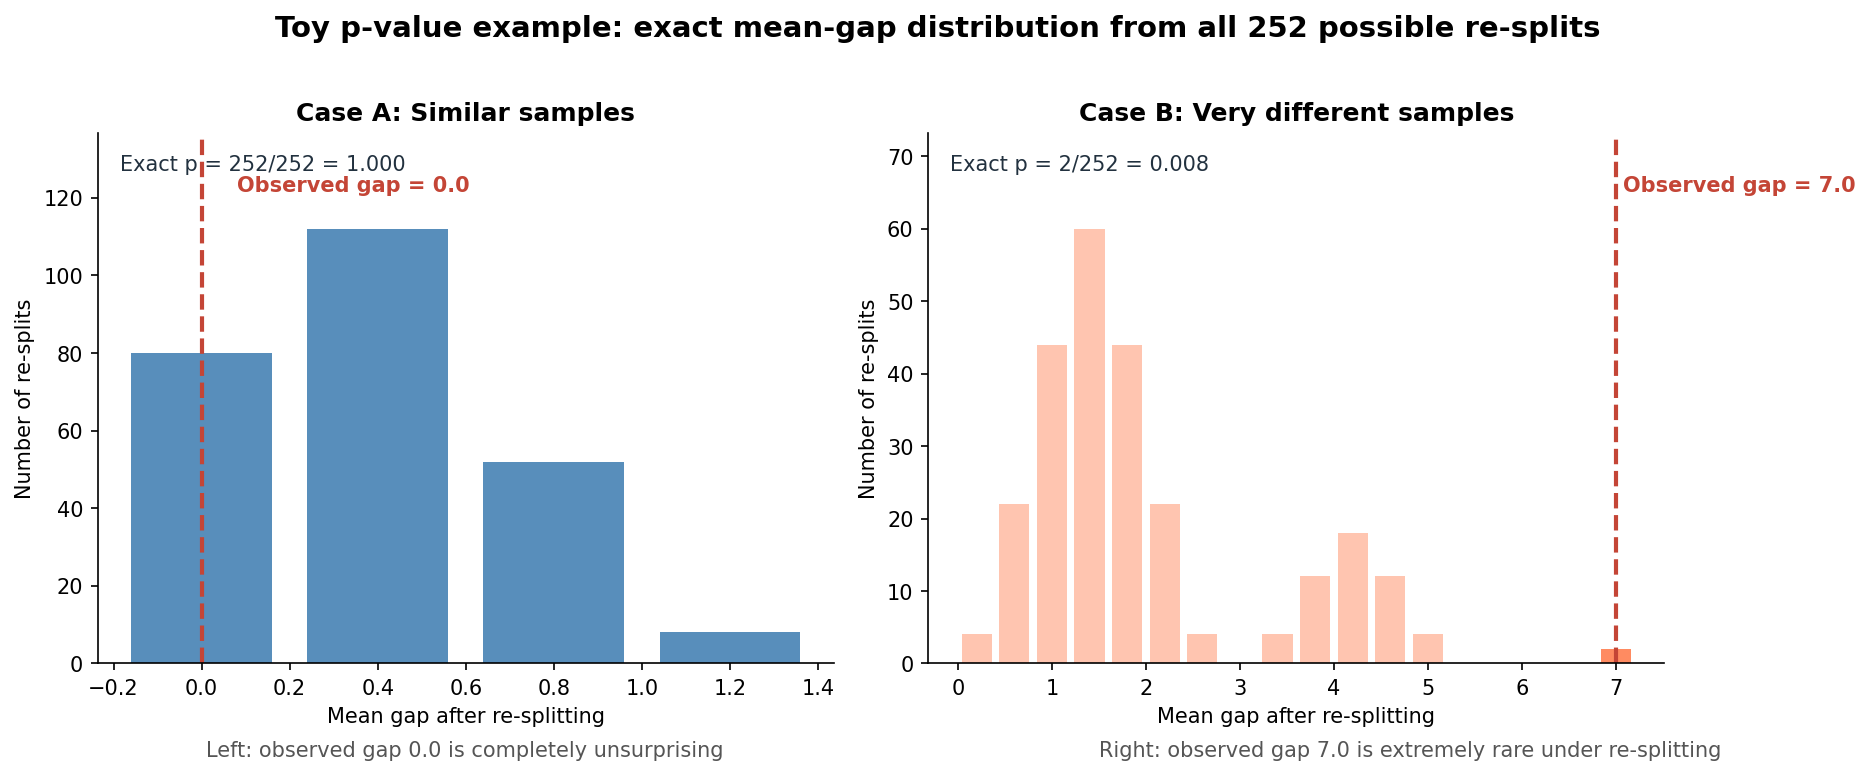

In [4]:
# Exact null distribution for the two toy cases

## 5. Exact p-values

Here, p-value means: **fraction of re-splits with a mean gap at least as large as the observed one**.

In [5]:
print(f'Similar case: p = {hits_sim}/{total} = {p_sim:.3f}')
print(f'Different case: p = {hits_diff}/{total} = {p_diff:.3f}')


Similar case: p = 252/252 = 1.000
Different case: p = 2/252 = 0.008


## 6. Link back to KS

The logic is the same for KS:

- choose a test statistic
- ask how unusual it would be under the **no-drift** story
- for KS, the statistic is **`D`**, the largest CDF gap, instead of the **mean gap**